In [1]:
import pandas as pd
import regex as re
import ast
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../data/names_results2.db")

In [2]:
# Total dataset size
total = pd.read_sql("SELECT COUNT(*) AS total FROM names", engine).iloc[0, 0]
print(f"Total names: {total:,}")

Total names: 727,352


In [3]:
# Load all columns needed for analysis
df = pd.read_sql(
    """
    SELECT
        name,
        top_country,
        top_country_langs,
        langdetect_lang,
        langdetect_lang_name,
        name_script,
        hunspell_orig_known,
        hunspell_latin_known,
        country_lang_comp
    FROM names
    """,
    engine
)

print(f"Loaded {len(df):,} rows")

Loaded 727,352 rows


In [4]:
# Filter for single-word names by checking there are no spaces
df_single_word = df[~df['name'].str.contains(r'\s')]

print(f"Single-word names: {len(df_single_word):,}")

Single-word names: 571,654


In [5]:
# Pattern: only allow Unicode letters (covers accents + non-Latin scripts)
valid_name_pattern = re.compile(r'^\p{L}+$')

df_single_word_clean = df_single_word[
    df_single_word["name"].apply(lambda x: bool(valid_name_pattern.match(x)) if isinstance(x, str) else False)
]

removed = len(df_single_word) - len(df_single_word_clean)
print(f"Clean single-word names: {len(df_single_word_clean):,}")
print(f"Removed entries: {removed:,}")

Clean single-word names: 556,400
Removed entries: 15,254


In [6]:
df_single_word_clean["name_script"].value_counts()

name_script
Latin         453455
Arabic         32174
Cyrillic       26523
CJK            20290
Hangul         12324
Hebrew          4187
Greek           3230
Georgian        2084
Ethiopic         670
Hiragana         647
Katakana         550
Bengali           92
Thai              56
Armenian          38
Devanagari        36
Khmer             12
CHEROKEE          11
CANADIAN           4
Myanmar            4
Gujarati           3
Syriac             2
Gurmukhi           2
Tamil              1
RUNIC              1
Oriya              1
Thaana             1
VAI                1
Sinhala            1
Name: count, dtype: int64

In [7]:
# Hunspell coverage counts on clean single-word names
n = len(df_single_word_clean)

orig_known  = df_single_word_clean["hunspell_orig_known"].sum()
latin_known = df_single_word_clean["hunspell_latin_known"].sum()
either_known = (df_single_word_clean["hunspell_orig_known"] | df_single_word_clean["hunspell_latin_known"]).sum()

counts = pd.DataFrame([{
    "orig_known":   orig_known,
    "latin_known":  latin_known,
    "either_known": either_known,
    "total":        n,
    "orig_pct":     orig_known  / n * 100,
    "latin_pct":    latin_known / n * 100,
    "either_pct":   either_known / n * 100,
}])

counts

,orig_known,latin_known,either_known,total,orig_pct,latin_pct,either_pct
0,15763,24540,24540,556400,2.833034,4.410496,4.410496


In [8]:
# Readable summary
row = counts.iloc[0]
print(f"Known to hunspell (original form): {int(row.orig_known):,}  ({row.orig_pct:.2f}%)")
print(f"Known to hunspell (latin form):    {int(row.latin_known):,}  ({row.latin_pct:.2f}%)")
print(f"Known to hunspell (either form):   {int(row.either_known):,}  ({row.either_pct:.2f}%)")

Known to hunspell (original form): 15,763  (2.83%)
Known to hunspell (latin form):    24,540  (4.41%)
Known to hunspell (either form):   24,540  (4.41%)


In [9]:
# country_lang_comp coverage
clc_true = df_single_word_clean["country_lang_comp"].sum()
clc_pct  = clc_true / n * 100

print(f"country_lang_comp = True: {int(clc_true):,}  ({clc_pct:.2f}%)")

country_lang_comp = True: 93,929  (16.88%)


In [10]:
# Prepare flag columns for plotting
sw = df_single_word_clean.copy()

sw["hunspell_orig_known"]  = sw["hunspell_orig_known"].astype(bool)
sw["hunspell_latin_known"] = sw["hunspell_latin_known"].astype(bool)
sw["hunspell_flag"]        = ~sw["hunspell_orig_known"]
sw["hunspell_latin_flag"]  = ~sw["hunspell_latin_known"]

if isinstance(sw["top_country_langs"].iloc[0], str):
    sw["top_country_langs"] = sw["top_country_langs"].apply(ast.literal_eval)
sw["country_primary_lang"] = sw["top_country_langs"].str[0]

sw[["hunspell_orig_known", "hunspell_flag"]].head()

,hunspell_orig_known,hunspell_flag
228,True,False
229,False,True
230,False,True
231,False,True
232,False,True


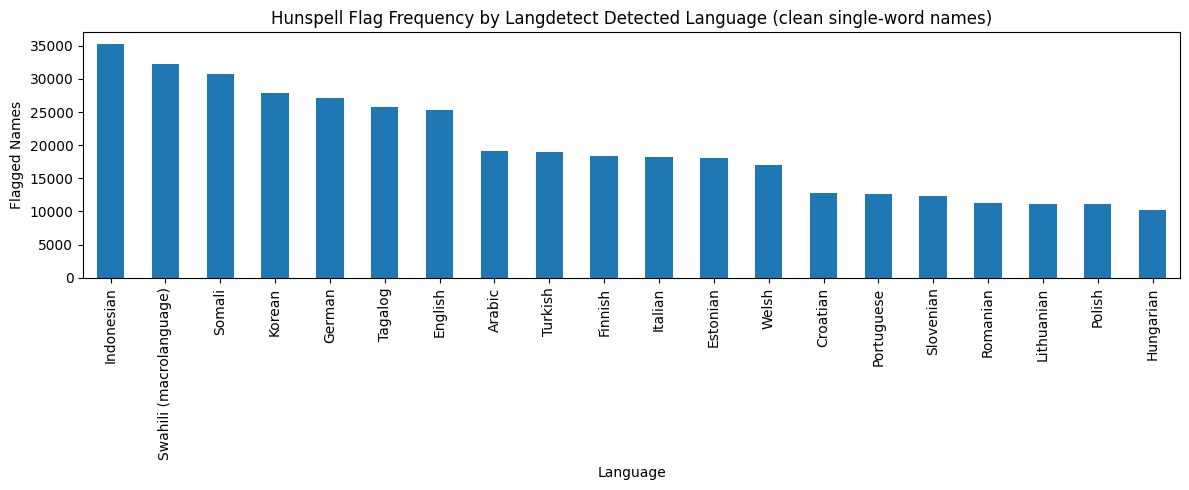

In [11]:
# Hunspell flag frequency by langdetect detected language
flag_freq_lang = (
    sw[sw["hunspell_flag"]]
    ["langdetect_lang_name"]
    .value_counts()
)

flag_freq_lang.head(20).plot.bar(figsize=(12, 5))

plt.title("Hunspell Flag Frequency by Langdetect Detected Language (clean single-word names)")
plt.ylabel("Flagged Names")
plt.xlabel("Language")
plt.tight_layout()
plt.show()

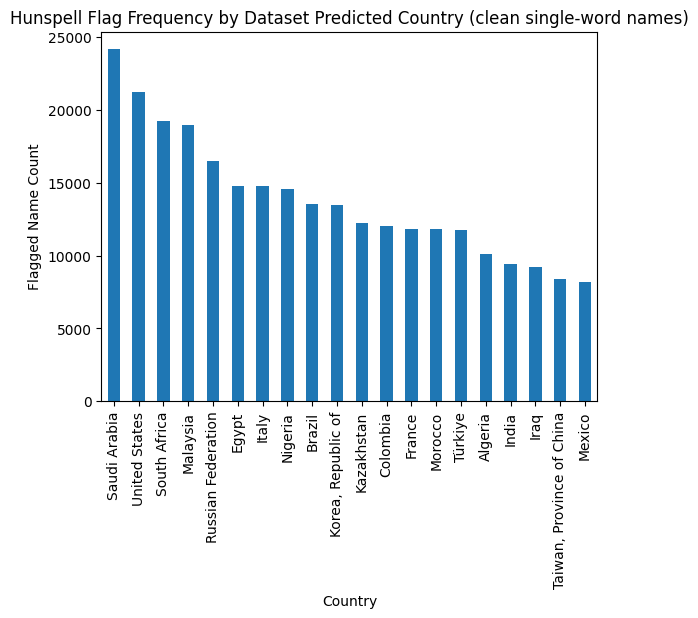

In [12]:
flag_freq_country = (
    sw[sw["hunspell_flag"]]
    ["top_country"]
    .value_counts()
)

flag_freq_country.head(20).plot.bar()

plt.title("Hunspell Flag Frequency by Dataset Predicted Country (clean single-word names)")
plt.ylabel("Flagged Name Count")
plt.xlabel("Country")
plt.show()

C:\Users\saras\AppData\Local\Temp\ipykernel_9508\2632577585.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["hunspell_flag"].mean() - x["hunspell_latin_flag"].mean())


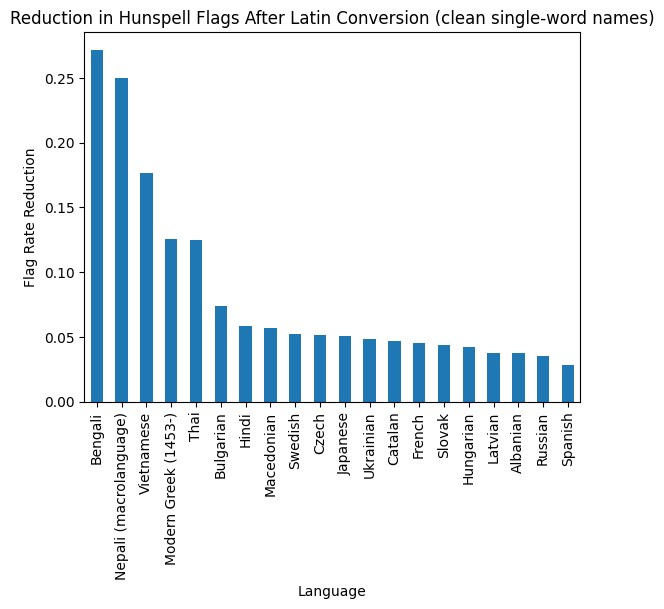

In [14]:
latin_improvement = (
    sw.groupby("langdetect_lang_name")
    .apply(lambda x: x["hunspell_flag"].mean() - x["hunspell_latin_flag"].mean())
    .sort_values(ascending=False)
)

latin_improvement.head(20).plot.bar()

plt.title("Reduction in Hunspell Flags After Latin Conversion (clean single-word names)")
plt.ylabel("Flag Rate Reduction")
plt.xlabel("Language")
plt.show()

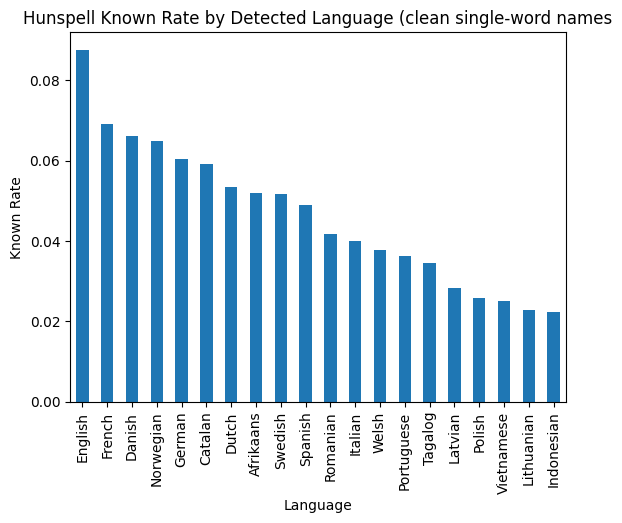

In [16]:
known_rate_lang = (
    sw.groupby("langdetect_lang_name")["hunspell_orig_known"]
    .mean()
    .sort_values(ascending=False)
)

known_rate_lang.head(20).plot.bar()

plt.title("Hunspell Known Rate by Detected Language (clean single-word names")
plt.ylabel("Known Rate")
plt.xlabel("Language")

plt.show()

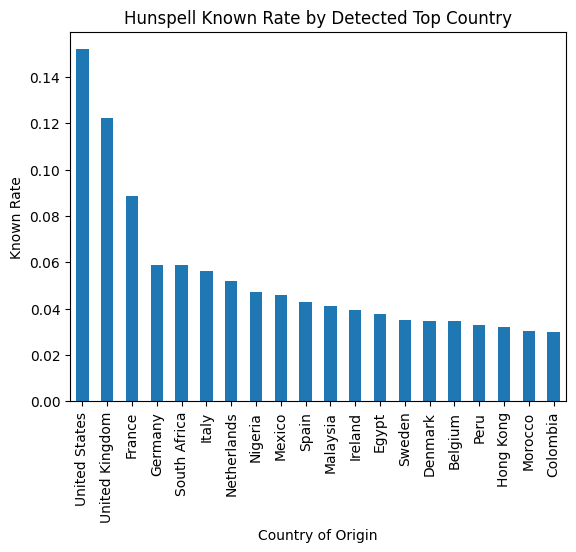

In [18]:
known_rate_lang = (
    sw.groupby("top_country")["hunspell_orig_known"]
    .mean()
    .sort_values(ascending=False)
)

known_rate_lang.head(20).plot.bar()

plt.title("Hunspell Known Rate by Detected Top Country")
plt.ylabel("Known Rate")
plt.xlabel("Country of Origin")

plt.show()

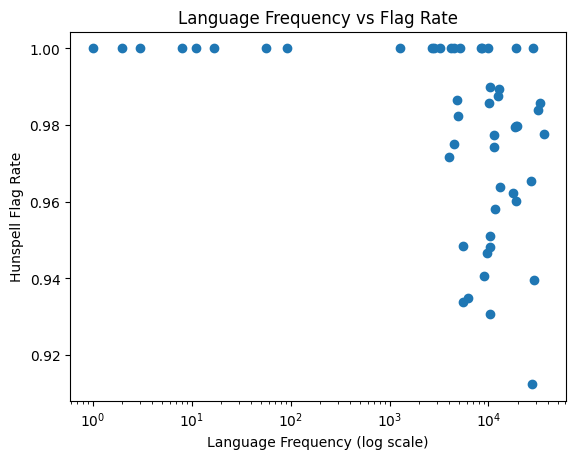

In [19]:
freq = sw["langdetect_lang_name"].value_counts()
flag_rate = sw.groupby("langdetect_lang_name")["hunspell_flag"].mean()

common = freq.index.intersection(flag_rate.index)

plt.scatter(freq[common], flag_rate[common])

plt.xscale("log")

plt.xlabel("Language Frequency (log scale)")
plt.ylabel("Hunspell Flag Rate")
plt.title("Language Frequency vs Flag Rate")

plt.show()

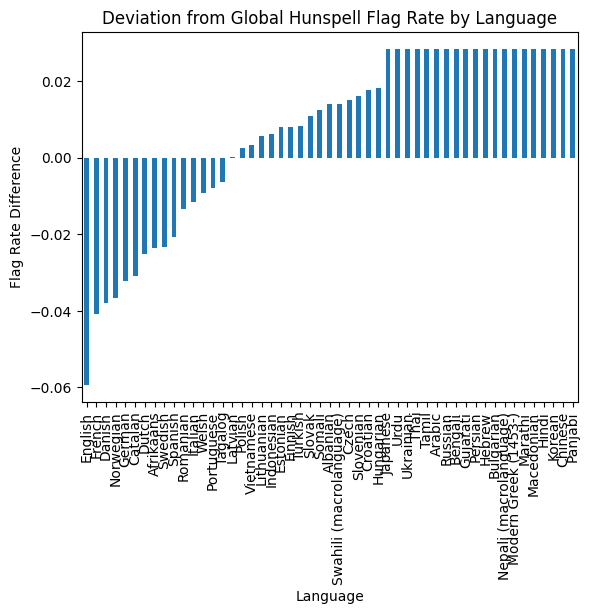

In [22]:
global_flag_rate = sw["hunspell_flag"].mean()

flag_rate_lang = sw.groupby("langdetect_lang_name")["hunspell_flag"].mean()

deviation = (flag_rate_lang - global_flag_rate).sort_values()

deviation.plot.bar()

plt.title("Deviation from Global Hunspell Flag Rate by Language")
plt.ylabel("Flag Rate Difference")
plt.xlabel("Language")

plt.show()

In [23]:
summary = pd.DataFrame({
    "frequency": sw["langdetect_lang_name"].value_counts(),
    "flag_rate": sw.groupby("langdetect_lang_name")["hunspell_flag"].mean()
})

summary["known_rate"] = 1 - summary["flag_rate"]

summary.sort_values("frequency", ascending=False).head(20)

,frequency,flag_rate,known_rate
langdetect_lang_name,,,
Indonesian,36075,0.977769,0.022231
Swahili (macrolanguage),32793,0.985668,0.014332
Somali,31307,0.983997,0.016003
German,28896,0.939576,0.060424
Korean,27912,1.000000,0.000000
English,27767,0.912342,0.087658
Tagalog,26630,0.965377,0.034623
Turkish,19302,0.979795,0.020205
Arabic,19183,1.000000,0.000000


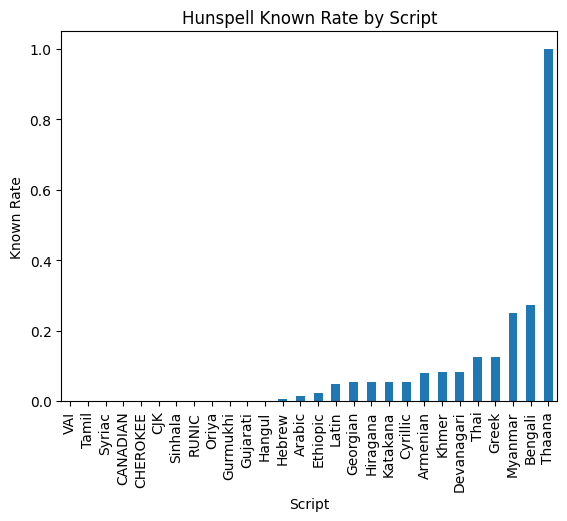

In [29]:
script_rate = (
    sw.groupby("name_script")["hunspell_latin_known"]
    .mean()
    .sort_values()
)

script_rate.plot.bar()

plt.title("Hunspell Known Rate by Script")
plt.ylabel("Known Rate")
plt.xlabel("Script")

plt.show()